In [2]:
from lookup_historic import lookup_historical_rent

from matplotlib import pyplot as plt

In [10]:
test = lookup_historical_rent(12049, 69.98, 1939, "low")

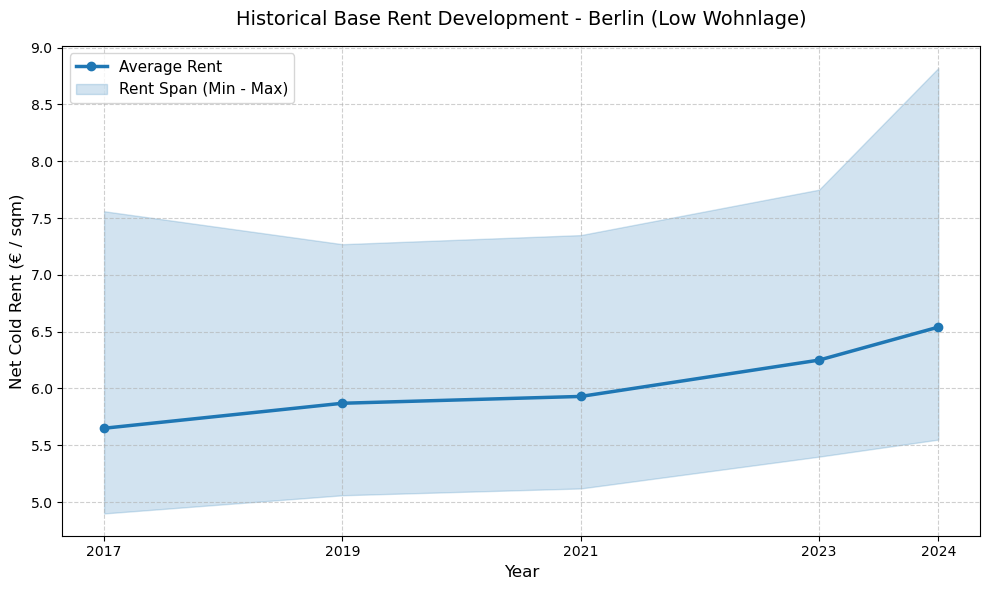

In [11]:
# 1. Extract the data
years = []
mins = []
avgs = []
maxs = []

for entry in test['history']:
    years.append(int(entry['version_year']))
    # Assuming there is only one result dict per year for your specific query
    result = entry['results'][0]
    mins.append(result['rent_min'])
    avgs.append(result['rent_avg'])
    maxs.append(result['rent_max'])

# 2. Sort chronologically (ascending order: 2019 -> 2024)
# Zip everything together, sort by the first item (years), and unpack
sorted_data = sorted(zip(years, mins, avgs, maxs))
years, mins, avgs, maxs = zip(*sorted_data)

# 3. Plot the data
plt.figure(figsize=(10, 6))

# Plot the average as a bold line with markers
plt.plot(years, avgs, color='#1f77b4', marker='o', linewidth=2.5, label='Average Rent')

# Shade the area between the min and max to show the span
plt.fill_between(years, mins, maxs, color='#1f77b4', alpha=0.2, label='Rent Span (Min - Max)')

# Add formatting and labels
wohnlage = test['history'][0]['results'][0]['wohnlage'].capitalize()
plt.title(f"Historical Base Rent Development - {test['city']} ({wohnlage} Wohnlage)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Net Cold Rent (€ / sqm)", fontsize=12)

# Force the X-axis to only show the exact years we have data for
plt.xticks(years)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Clean up layout and display
plt.tight_layout()
plt.show()